In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import torchvision.transforms as transforms
import os
import pandas as pd
from PIL import Image
from collections import Counter

import spacy

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

# caption evaluation imports
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate import meteor_score
from rouge_score import rouge_scorer
import json
from pycocoevalcap.cider.cider import Cider



### Caption Scores

In [2]:
# ROGUE scorer initialization
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

# The Cider() class expects dictionaries formatted in the COCO evaluation style
def compute_cider(references, predictions):
    # Initialize the CIDEr scorer
    cider_scorer = Cider()
    
    # CIDEr expects refs formatted as {image_id: [{ "image_id": image_id, "caption": text }]}
    formatted_refs = {
        img_id: [{"image_id": img_id, "caption": cap} for cap in caps]
        for img_id, caps in references.items()
    }
    
    # CIDEr expects preds formatted as {image_id: [{ "image_id": image_id, "caption": text }]}
    formatted_preds = {
        img_id: [{"image_id": img_id, "caption": preds[img_id][0]}]
        for img_id in predictions.keys()
    }
    
    # Compute score
    score, scores = cider_scorer.compute_score(formatted_refs, formatted_preds)
    return score

In [3]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
spacy_eng = spacy.load("en_core_web_sm")

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {
            0: "<PAD>",
            1: "<SOS>",
            2: "<EOS>",
            3: "<UNK>"
        }

        self.stoi = {
            "<PAD>": 0,
            "<SOS>": 1,
            "<EOS>": 2,
            "<UNK>": 3
        }

        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)

        self.transform = transform

        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]

        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]

        numericalized_caption += self.vocab.numericalize(caption)

        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]

        imgs = torch.cat(imgs, dim=0)

        targets = [item[1] for item in batch]

        targets = pad_sequence(
            targets,
            batch_first=True,
            padding_value=self.pad_idx
        )

        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    transform,
    batch_size=128,
    num_workers=0,
    shuffle=True,
    pin_memory=True,
):

    dataset = FlickrDataset(
        root_folder,
        annotation_file,
        transform=transform
    )

    pad_idx = dataset.vocab.stoi["<PAD>"]

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=MyCollate(pad_idx=pad_idx),
    )

    return loader, dataset

def tokens_to_caption(tokens, vocab):

    words = []

    for token in tokens:

        word = vocab.itos[token]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>"]:
            words.append(word)

    return " ".join(words)

Models

In [5]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN = False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
        self.inception.aux_logits = False
        self.inception.AuxLogits = None
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        for param in self.inception.parameters():
            param.requires_grad = train_CNN

        for param in self.inception.fc.parameters():
            param.requires_grad = True

    def forward(self, images):
        features = self.inception(images)
        return self.dropout(self.relu(features))


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        features = features.unsqueeze(1)
        embeddings = torch.cat((features, embeddings), dim=1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=50):
        result_caption = []
        self.eval()
        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.lstm(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(1)

                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break
        self.train()
        return [vocabulary.itos[idx] for idx in result_caption]


In [6]:
import os


print(os.path.exists("../flickr8k/Images"))
print(os.path.exists("../flickr8k/captions.txt"))

True
True


In [7]:
transform = transforms.Compose(
    [
        transforms.Resize((356, 356)),
        transforms.RandomCrop((299,299)),
        transforms.ToTensor(),
        transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]),
    ]
)

# train_loader, dataset = get_loader(
#     root_folder="flickr8k/Images",
#     annotation_file="flickr8k/captions.txt",
#     transform=transform,
#     num_workers=0,
# )

full_dataset = FlickrDataset(
    root_dir="../flickr8k/Images",
    captions_file="../flickr8k/captions.txt",
    transform=transform
)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset,[train_size, val_size, test_size])
pad_idx = full_dataset.vocab.stoi["<PAD>"]

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

#Hyperparamaters
embed_size = 256
hidden_size = 256
vocab_size = len(full_dataset.vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 200


#initialize model, loss etc
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=full_dataset.vocab.stoi["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

## Comet

In [8]:
import comet_ml
from comet_ml import start
from comet_ml.integration.pytorch import log_model

project_ml = comet_ml.Experiment(
    api_key="wCXnRD5xewUGxCxBYe8ePt4JY",
    workspace="kanskejoanna",
    project_name="Image-Captioning",
    name="Image Captioning Training",
    display_name="Image Captioning Training",
)

hyper_params = {
   "learning_rate": learning_rate,
   "steps": num_epochs
}

project_ml.log_parameters(hyper_params)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/kanskejoanna/image-captioning/50c960e271f64d80a6d35dcc6d543dec

COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


Train

In [9]:
max_loss = float('inf')
val_max_loss = float('inf')
noLossProgression = 0
indexLossProgression = 0
for epoch in range(num_epochs):
    #------------------------- TRAINING -------------------------
    model.train()
    running_loss = 0
    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)

        outputs = model(imgs, captions[:, :-1])
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        running_loss += loss.item()
    average_loss = running_loss/len(train_loader)
    #------------------------- VALIDATION -------------------------
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for imgs, captions in val_loader:
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions[:,:-1])
            val_loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]),captions[:, 1:].reshape(-1))
            val_running_loss += val_loss.item()
        val_average_loss = val_running_loss/len(val_loader)
        if val_average_loss <= val_max_loss:
                val_max_loss = val_average_loss
                torch.save(model.state_dict(), "BestModel.pth")
                print("Saved the Best Performing Model!")
                indexLossProgression = epoch +1
    
    project_ml.log_metrics({"Training Loss": average_loss, "Validation Loss": val_average_loss}, step=epoch)

    print(f"Epoch [{epoch + 1}/{num_epochs}] Training Loss: {average_loss:.4f} Validation Loss: {val_average_loss:.4f}")
    if epoch >= 15 and epoch - indexLossProgression >= 15:
        break

project_ml.end()

Saved the Best Performing Model!
Epoch [1/200] Training Loss: 4.2231 Validation Loss: 3.6448
Saved the Best Performing Model!
Epoch [2/200] Training Loss: 3.5369 Validation Loss: 3.3628
Saved the Best Performing Model!
Epoch [3/200] Training Loss: 3.3096 Validation Loss: 3.2028
Saved the Best Performing Model!
Epoch [4/200] Training Loss: 3.1663 Validation Loss: 3.0947
Saved the Best Performing Model!
Epoch [5/200] Training Loss: 3.0604 Validation Loss: 3.0084
Saved the Best Performing Model!
Epoch [6/200] Training Loss: 2.9756 Validation Loss: 2.9473
Saved the Best Performing Model!
Epoch [7/200] Training Loss: 2.9067 Validation Loss: 2.8982
Saved the Best Performing Model!
Epoch [8/200] Training Loss: 2.8502 Validation Loss: 2.8610


Saved the Best Performing Model!
Epoch [9/200] Training Loss: 2.8021 Validation Loss: 2.8228


COMET ERROR: Due to connectivity issues, there's an error in processing the heartbeat. The experiment's status updates might be inaccurate until the connection issues are resolved.


Saved the Best Performing Model!
Epoch [10/200] Training Loss: 2.7593 Validation Loss: 2.7989
Saved the Best Performing Model!
Epoch [11/200] Training Loss: 2.7219 Validation Loss: 2.7730
Saved the Best Performing Model!
Epoch [12/200] Training Loss: 2.6877 Validation Loss: 2.7528
Saved the Best Performing Model!
Epoch [13/200] Training Loss: 2.6575 Validation Loss: 2.7369
Saved the Best Performing Model!
Epoch [14/200] Training Loss: 2.6306 Validation Loss: 2.7196
Saved the Best Performing Model!
Epoch [15/200] Training Loss: 2.6037 Validation Loss: 2.7054
Saved the Best Performing Model!
Epoch [16/200] Training Loss: 2.5801 Validation Loss: 2.6949
Saved the Best Performing Model!
Epoch [17/200] Training Loss: 2.5571 Validation Loss: 2.6833
Saved the Best Performing Model!
Epoch [18/200] Training Loss: 2.5377 Validation Loss: 2.6765
Saved the Best Performing Model!
Epoch [19/200] Training Loss: 2.5173 Validation Loss: 2.6679
Saved the Best Performing Model!
Epoch [20/200] Training Los

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : distinguished_depot_935
COMET INFO:     url                   : https://www.comet.com/kanskejoanna/image-captioning/50c960e271f64d80a6d35dcc6d543dec
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Training Loss [57]   : (2.1337719316536425, 4.2230904622266525)
COMET INFO:     Validation Loss [57] : (2.605096848387467, 3.6447521950069226)
COMET INFO:   Parameters:
COMET INFO:     learning_rate : 0.0003
COMET INFO:     steps         : 200
COMET INFO:   Uploads:
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (1.1

Epoch [57/200] Training Loss: 2.1338 Validation Loss: 2.6164


C:\Users\david\AppData\Local\Temp\ipykernel_33652\3588783118.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("BestModel.pth"))



----------------------------------
Actual Caption    : a boy in black pants and green t - shirt jumps high with his skateboard .
Predicted Caption : a skateboarder is performing a trick on a ramp . 
BLEU Score         :  6.686350417856737e-232
ROGUE Score         : 
rouge1
Precision: 0.2222
Recall: 0.1429
F1 Score: 0.1739

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.2222
Recall: 0.1429
F1 Score: 0.1739



c:\Users\david\anaconda3\envs\tretolv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\david\anaconda3\envs\tretolv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\david\anaconda3\envs\tretolv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram or

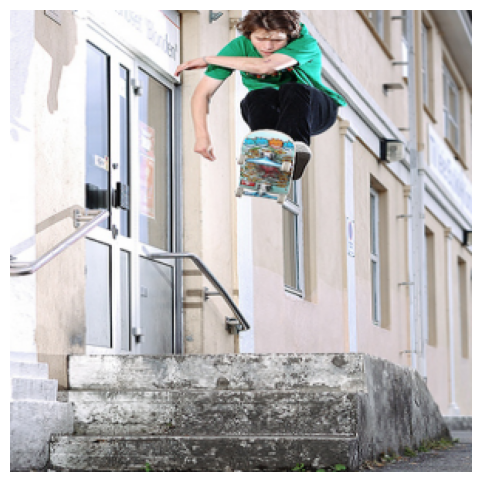


----------------------------------
Actual Caption    : a dog pants while standing in the woods .
Predicted Caption : dogs running through the grass . 
BLEU Score         :  8.396161215621529e-232
ROGUE Score         : 
rouge1
Precision: 0.4000
Recall: 0.2500
F1 Score: 0.3077

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.4000
Recall: 0.2500
F1 Score: 0.3077



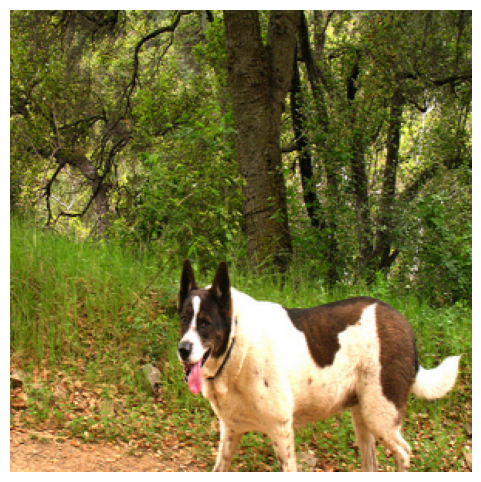


----------------------------------
Actual Caption    : a man fly fishes in a large river .
Predicted Caption : a dog swims in the water . 
BLEU Score         :  1.1077199809555581e-231
ROGUE Score         : 
rouge1
Precision: 0.3333
Recall: 0.2500
F1 Score: 0.2857

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.3333
Recall: 0.2500
F1 Score: 0.2857



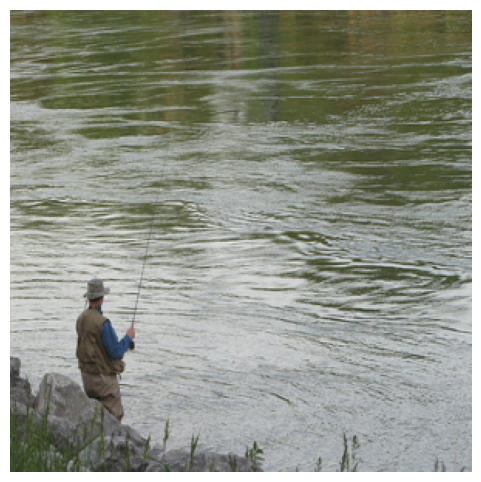


Final Test Loss: 2.7245


In [10]:
#Test the model
model.load_state_dict(torch.load("BestModel.pth"))
model.eval()

test_loss = 0.0
correct = 0
total = 0
test_running_loss = 0.0

with torch.no_grad():

    for batch_idx, (imgs, captions) in enumerate(test_loader):

        imgs = imgs.to(device)
        captions = captions.to(device)

        # Forward pass
        outputs = model(imgs, captions[:, :-1])

        # Compute test loss
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
        test_running_loss += loss.item()

        # Show a few predictions from first batch only
        if batch_idx == 0:

            for i in range(min(3, imgs.shape[0])):
                # Generate predicted caption
                predicted_caption = model.caption_image(imgs[i].unsqueeze(0), full_dataset.vocab)

                predicted_sentence = " ".join(predicted_caption)

                # Convert actual caption to text
                actual_sentence = tokens_to_caption(captions[i].cpu().numpy(), full_dataset.vocab)

                # Prepare image for matplotlib
                img = imgs[i].cpu()

                # Convert CHW -> HWC
                img = img.permute(1, 2, 0)

                # Undo normalization
                mean = torch.tensor([0.485, 0.456, 0.406])
                std = torch.tensor([0.229, 0.224, 0.225])

                img = img * std + mean
                img = img.clamp(0, 1)

                # Plot image
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.axis("off")

                print("\n----------------------------------")
                print(f"Actual Caption    : {actual_sentence}")
                print(f"Predicted Caption : {predicted_sentence[:-5]}")
                print("BLEU Score         : ", sentence_bleu([actual_sentence.split()], predicted_sentence[:-5].split()))
                #print("METEOR score        : ", meteor_score([actual_sentence.split()], predicted_sentence[:-5].split()))
                print("ROGUE Score         : ")
                rouge_scores = scorer.score(actual_sentence, predicted_sentence[:-5])
                for key, value in rouge_scores.items():
                    print(f"{key}")
                    print(f"Precision: {value.precision:.4f}")
                    print(f"Recall: {value.recall:.4f}")
                    print(f"F1 Score: {value.fmeasure:.4f}")
                    print()
                #print("CIDEr Score         : ", compute_cider(actual_sentence,predicted_sentence))

                plt.show()

# Average test loss
average_test_loss = test_running_loss / len(test_loader)

print(f"\nFinal Test Loss: {average_test_loss:.4f}")

## Beam Search 


In [11]:
def caption_image_beam_search(self, image, vocabulary, beam_width=5, max_length=20):
    self.eval()

    eos_idx = vocabulary.stoi["<EOS>"] # Ending-Token
    pad_idx = vocabulary.stoi["<PAD>"] # Padding-Tokens

    with torch.no_grad():
        features = self.encoderCNN(image).unsqueeze(0) 
        beams = [(features, None, [], 0.0)] # (input, hidden states, generarade tokens and total score)

        for _ in range(max_length):
            candidates = []

            for x, states, tokens, score in beams: # alla existerande beams
                if len(tokens) > 0 and tokens[-1] == eos_idx: # Om senaste token var ending token så avslutas denna beam.
                    candidates.append((x, states, tokens, score))
                    continue

                hiddens, new_states = self.decoderRNN.lstm(x, states) 
                output = self.decoderRNN.linear(hiddens.squeeze(0)) # Skickar hidden state genom linear-lagret, för att få logits till nästa ord...

                log_probs = torch.log_softmax(output, dim=1) # Omvandlar logits till log-sannolikheter

                top_probs, top_indices = log_probs.topk(beam_width, dim=1)

                for i in range(beam_width): # Loopar igenom de bäst orden
                    word_idx = top_indices[0, i].item() #Id
                    word_score = top_probs[0, i].item() #Sannolikhet i Logits

                    new_tokens = tokens + [word_idx] # Skapar ny token sekvens
                    new_score = score + word_score # Adderar sannolikheten på den nya sekvensen

                    next_input = self.decoderRNN.embed(torch.tensor([word_idx]).to(image.device)).unsqueeze(0) #Embeddar nästa ord för att användas som input

                    candidates.append((next_input, new_states, new_tokens, new_score)) # Saves new candidate

            # Sorterar candidates efter score
            beams = sorted(
                candidates,
                key=lambda x: x[3] / len(x[2]),
                reverse=True
            )[:beam_width] # Take the first elements


            # ifall alla beams avslutats med ending token så avbryts generationen tidigt
            if all(len(tokens) > 0 and tokens[-1] == eos_idx for _, _, tokens, _ in beams): 
                break

    self.train()
    # Hämtar token-sekvensen från bästa beam
    best_tokens = beams[0][2] # [0] = Första beam sekvensen och [2] = Token sekvensen

    # Omvandlar token-index till ord
    return [
        vocabulary.itos[idx]
        for idx in best_tokens
        if idx not in [eos_idx, pad_idx]
    ]

CNNtoRNN.caption_image_beam_search = caption_image_beam_search # Gör funktionen till en metod som kan anropas via model.caption_image_beam_search()

C:\Users\david\AppData\Local\Temp\ipykernel_33652\1085594971.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("BestModel.pth", map_locati

Model is on: cuda:0

----------------------------------
Actual Caption : a boy in black pants and green t - shirt jumps high with his skateboard .
    Greedy Caption : a skateboarder is performing a trick on a ramp .
BLEU Score         :  4.832402486973385e-232
ROGUE Score         : 
rouge1
Precision: 0.2222
Recall: 0.1429
F1 Score: 0.1739

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.2222
Recall: 0.1429
F1 Score: 0.1739

    Beam Caption   : a skateboarder is performing a trick on a ramp .
BLEU Score         :  4.832402486973385e-232
ROGUE Score         : 
rouge1
Precision: 0.2222
Recall: 0.1429
F1 Score: 0.1739

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.2222
Recall: 0.1429
F1 Score: 0.1739



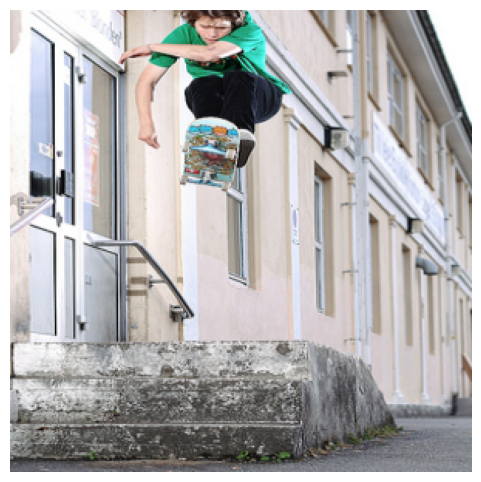


----------------------------------
Actual Caption : a dog pants while standing in the woods .
    Greedy Caption : and black dog running through the grass .
BLEU Score         :  1.0009379942300742e-231
ROGUE Score         : 
rouge1
Precision: 0.2857
Recall: 0.2500
F1 Score: 0.2667

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.2857
Recall: 0.2500
F1 Score: 0.2667

    Beam Caption   : a black and white dog is running through the grass .
BLEU Score         :  1.3483065280626046e-231
ROGUE Score         : 
rouge1
Precision: 0.3000
Recall: 0.3750
F1 Score: 0.3333

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.3000
Recall: 0.3750
F1 Score: 0.3333



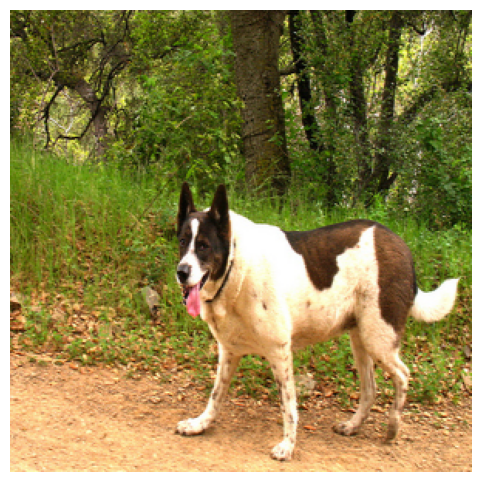


----------------------------------
Actual Caption : a man fly fishes in a large river .
    Greedy Caption : a dog swims in the water .
BLEU Score         :  8.396161215621529e-232
ROGUE Score         : 
rouge1
Precision: 0.3333
Recall: 0.2500
F1 Score: 0.2857

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.3333
Recall: 0.2500
F1 Score: 0.2857

    Beam Caption   : surfer riding a wave on a beach .
BLEU Score         :  1.0009379942300742e-231
ROGUE Score         : 
rouge1
Precision: 0.2857
Recall: 0.2500
F1 Score: 0.2667

rouge2
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

rougeL
Precision: 0.2857
Recall: 0.2500
F1 Score: 0.2667



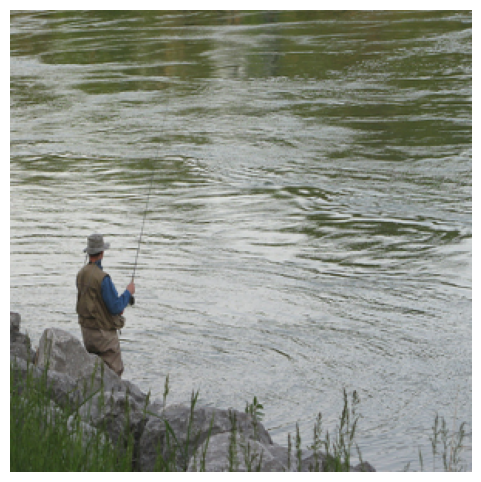

In [16]:
#Test the model
model.load_state_dict(torch.load("BestModel.pth", map_location=device))
model.to(device)
print("Model is on:", next(model.parameters()).device)
model.eval()


#test_running_loss = 0.0

with torch.no_grad():

    for batch_idx, (imgs, captions) in enumerate(test_loader):

        imgs = imgs.to(device)
        captions = captions.to(device)

        # Forward pass
        #outputs = model(imgs, captions[:, :-1])

        # Compute test loss
        #loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
        #test_running_loss += loss.item()

        # Show a few predictions from first batch only
        if batch_idx == 0:

            for i in range(min(3, imgs.shape[0])):
                # Generate predicted caption
                greedy_caption = model.caption_image(imgs[i].unsqueeze(0), full_dataset.vocab)

                beam_caption = model.caption_image_beam_search(imgs[i].unsqueeze(0), full_dataset.vocab)

                greedy_sentence = " ".join(greedy_caption).replace("<EOS>", "").strip()
                beam_sentence = " ".join(beam_caption).strip()

                # Convert actual caption to text
                actual_sentence = tokens_to_caption(captions[i].cpu().numpy(), full_dataset.vocab) # Numpy fungerar på CPU

                # Prepare image for matplotlib
                img = imgs[i].cpu()

                # Convert CHW -> HWC
                img = img.permute(1, 2, 0)

                # Undo normalization
                mean = torch.tensor([0.485, 0.456, 0.406])
                std = torch.tensor([0.229, 0.224, 0.225])

                img = img * std + mean
                img = img.clamp(0, 1)

                # Plot image
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.axis("off")

                print("\n----------------------------------")
                print(f"Actual Caption : {actual_sentence}")
                print(f"    Greedy Caption : {greedy_sentence}")
                
                print("BLEU Score         : ", sentence_bleu([actual_sentence.split()], greedy_sentence[:-5].split()))
                #print("METEOR score        : ", meteor_score([actual_sentence.split()], greedy_sentence[:-5].split()))
                print("ROGUE Score         : ")
                rouge_scores = scorer.score(actual_sentence, greedy_sentence[:-5])
                for key, value in rouge_scores.items():
                    print(f"{key}")
                    print(f"Precision: {value.precision:.4f}")
                    print(f"Recall: {value.recall:.4f}")
                    print(f"F1 Score: {value.fmeasure:.4f}")
                    print()
                #print("CIDEr Score         : ", compute_cider(actual_sentence,greedy_sentence), "\n")

                print(f"    Beam Caption   : {beam_sentence}")  
                print("BLEU Score         : ", sentence_bleu([actual_sentence.split()], beam_sentence[:-5].split()))
                #print("METEOR score        : ", meteor_score([actual_sentence.split()], beam_sentence[:-5].split()))
                print("ROGUE Score         : ")
                rouge_scores = scorer.score(actual_sentence, beam_sentence[:-5])
                for key, value in rouge_scores.items():
                    print(f"{key}")
                    print(f"Precision: {value.precision:.4f}")
                    print(f"Recall: {value.recall:.4f}")
                    print(f"F1 Score: {value.fmeasure:.4f}")
                    print()
                #print("CIDEr Score         : ", compute_cider(actual_sentence,beam_sentence), "\n")

                plt.show()

# Average test loss
#average_test_loss = test_running_loss / len(test_loader)

#print(f"\nFinal Test Loss: {average_test_loss:.4f}")